# Version 2: Analyze Region 16 - Low Latitudes

Author: A. Windnagel

Date: August 2026

This notebook analyzes the largest glaciers in Region 15 - Asia, South East. It processes Version 2 of the largest glacier data set using RGI 7 and GLIMS V20250603.

In [1]:
import os
import os.path as op
import glob
import sys
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import Polygon
import rasterio as rio
from rasterio.plot import plotting_extent
from earthpy import clip as cl
import earthpy.plot as ep

# set working dir
HOME = op.join(op.expanduser("~"))
os.chdir(os.path.join(HOME, "git/wgms-glacier-project"))

# Set up path to load scripts
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
import scripts.wgms_scripts as ws

# Set Up Region Info

In [2]:
# Set region number, region name, and region index
# Once these are set, this notebook should run automatically for the specified region
region_number = "16"
region_name = "Low Latitudes"

# Note for the region index, region_index_1 should be one less than the region number and 
# region_index_2 should be equal to the region number. For example, for region 1, index_1 should be set to 0 and 
# index_2 should be set to 1, etc.
region_index_1 = 15
region_index_2 = 16

# This variable sets a value to determine whether the differences between the GLIMS and RGI glacier have been checked.
# When first starting a new notebook set handled to 0
# Once the differences have been checked and handled, set to 1 to pass the check 
# in the Compare Glaciers from GLIMS and RGI section towards the middele of this notebook.
handled = 0

# Set GLIMS version
glims_version = '20250603'

# Set RGI version
rgi_version = 7

# Set version number for the final data
final_version = 2

# * * * * * * * * Show Region Outline * * * * * * * *

In [3]:
# Open natural earth basemap TIF file
ne_fp = 'data/natural-earth/NE1_HR_LC_SR_W/NE1_HR_LC_SR_W.tif' # 10 m res
with rio.open(ne_fp) as ne_src:
    # Convert / read the data into a numpy array:
    ne_raster = ne_src.read()
    ne_src_extent = plotting_extent(ne_src)
    bounds = ne_src.bounds
    ne_raster_meta = ne_src.meta

In [4]:
# Open glacier regions
glacier_regions_fp = "data/gtn-g-glacier-regions/cleaned/GTN-G_glacier_regions_201707_cleaned.shp"
glacier_regions = gpd.read_file(glacier_regions_fp)

# Extract Region outline
region_outline = glacier_regions[region_index_1:region_index_2]

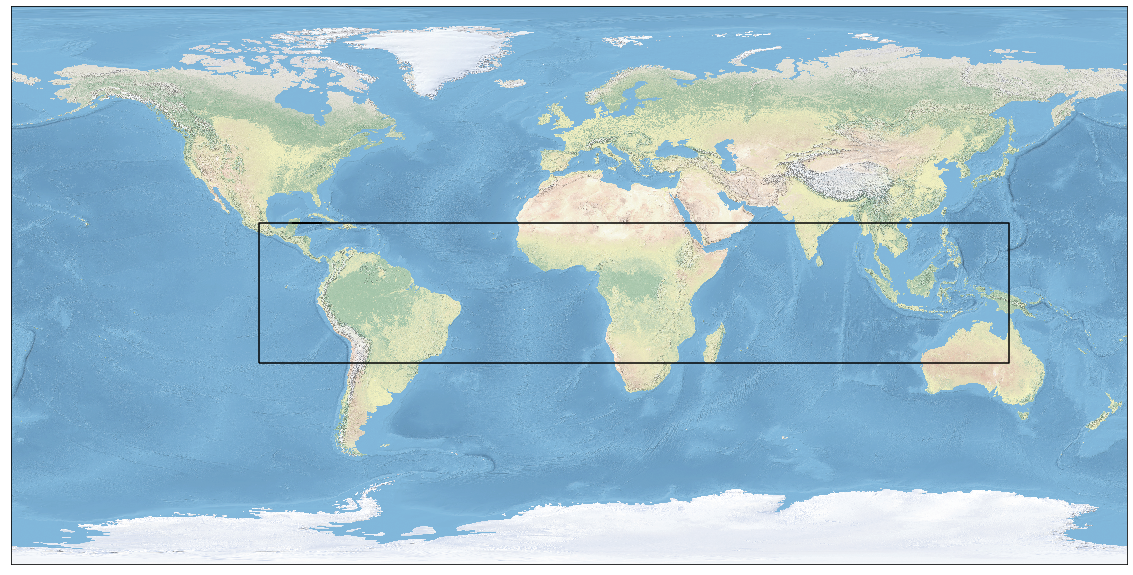

In [5]:
# Plot region outline over the natural earth
# Plot natural earth basemap
fig, ax = plt.subplots(figsize=(20, 20))

# Plot natural earth
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot region outline
region_outline.boundary.plot(ax=ax, color="black")

plt.show()

In [6]:
region_outline.bounds

,minx,miny,maxx,maxy
15,-100.0,-25.0,142.0,20.0


# * * * * * * * * Glacier Analysis * * * * * * * *

## Open GLIMS Largest Glaciers Data

In [7]:
# Open GLIMS largest glacier outlines for this region.
glims_glaciers_fn = "data/glims/processed/glims_version_" + glims_version + "/largest/glims_region_" + \
                    region_number + "_largest.shp"
glims_glaciers_df = gpd.read_file(glims_glaciers_fn)

In [8]:
# Check if GLIMS glacier names are of the "NoneType" because can't print legends and such if they are
# If they are, set them to a string "NONE"
glims_df_len = len(glims_glaciers_df)
for x in range(glims_df_len):
    if glims_glaciers_df['glac_name'][x] == None:
        print("GLIMS glacier " + str(x) + " equals none")
        glims_glaciers_df.loc[x, 'glac_name'] = 'NONE'

In [9]:
glims_glaciers_df

,region_no,glac_id,area,db_area,width,length,min_elev,mean_elev,max_elev,src_date,anlys_time,glac_name,geometry
0,16,G289157E13939S,0.000,12.3644,0.0,0.0,0.0,0.0,0.0,2016-01-16T00:00:00,2020-07-01T00:00:00,None,"POLYGON ((-70.864193 -13.97191, -70.865734 -13..."
1,16,G284682E04880N,11.378,11.3776,0.0,0.0,0.0,0.0,0.0,2000-06-15T00:00:00,2015-07-16T00:00:00,None,"POLYGON ((-75.331776 4.891184, -75.33204600000..."
2,16,G282507E09263S,0.000,10.9248,0.0,0.0,0.0,0.0,0.0,2016-01-16T00:00:00,2020-07-01T00:00:00,None,"POLYGON ((-77.518326 -9.259943, -77.518216 -9...."
3,16,G288994E13746S,0.000,10.7064,0.0,0.0,0.0,0.0,0.0,2016-01-16T00:00:00,2020-07-01T00:00:00,None,"POLYGON ((-71.039387 -13.751039, -71.03944 -13..."
4,16,G281578E01693S,10.263,10.2634,0.0,0.0,0.0,0.0,0.0,2000-06-15T00:00:00,2015-07-16T00:00:00,None,"POLYGON ((-78.416157 -1.706393, -78.416591 -1...."


## Open RGI 3 Largest Glaciers Data

In [10]:
# Open RGI largest glacier outlines for this region.
rgi_glaciers_fn = "data/rgi/processed/RGI-V" + str(rgi_version) + "/largest/rgi_region_" + region_number + "_largest.shp"
rgi_glaciers_df = gpd.read_file(rgi_glaciers_fn)

In [11]:
# Check if RGI glacier names are of the "NoneType" because can't print legends and such if they are
# If they are, set them to a string "NONE"
rgi_df_len = len(rgi_glaciers_df)
for x in range(rgi_df_len):
    if rgi_glaciers_df['Name'][x] == None:
        print("RGI glacier " + str(x) + " equals none")
        rgi_glaciers_df.loc[x, 'Name'] = 'NONE'

RGI glacier 0 equals none
RGI glacier 1 equals none
RGI glacier 2 equals none
RGI glacier 3 equals none
RGI glacier 4 equals none


In [12]:
rgi_glaciers_df

,RGIId,o1region,GLIMSId,BgnDate,cenlon,cenlat,Area,primeclass,Connect,Name,geometry
0,RGI2000-v7.0-G-16-00216,16,G282414E08866S,1998-09-02T00:00:00,-77.583467,-8.872819,12.761102,0,0,NONE,"POLYGON Z ((-77.58143800000001 -8.855487 0, -7..."
1,RGI2000-v7.0-G-16-00617,16,G282672E09291S,1998-09-02T00:00:00,-77.327729,-9.296729,12.024377,0,0,NONE,"POLYGON Z ((-77.320159 -9.283265999999999 0, -..."
2,RGI2000-v7.0-G-16-00050,16,G284682E04880N,2000-06-15T00:00:00,-75.316485,4.884135,11.377554,0,0,NONE,"POLYGON Z ((-75.323358 4.904368 0, -75.3234389..."
3,RGI2000-v7.0-G-16-00423,16,G282507E09263S,1998-09-02T00:00:00,-77.501315,-9.266075,10.973060,0,0,NONE,"POLYGON Z ((-77.49042799999999 -9.250505 0, -7..."
4,RGI2000-v7.0-G-16-00306,16,G282414E09082S,1998-09-02T00:00:00,-77.584364,-9.089006,10.591016,0,0,NONE,"POLYGON Z ((-77.586614 -9.067031999999999 0, -..."


## Plot GLIMS Glaciers

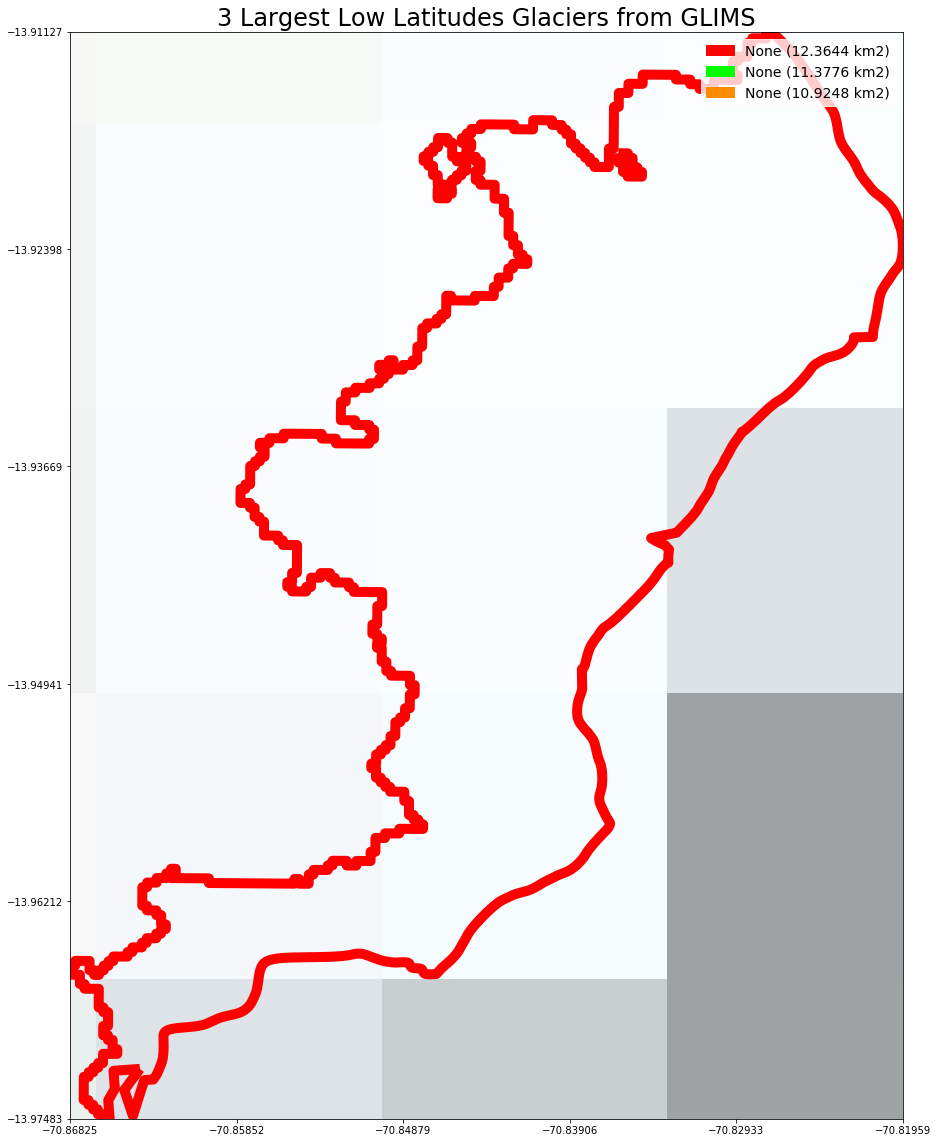

In [13]:
# Plot 3 largest glaciers on natural earth from GLIMS
legend_colors = ['red', 'lime', 'darkorange', 'purple']
legend_labels = [glims_glaciers_df['glac_name'][0] + ' (' + str(glims_glaciers_df['db_area'][0]) + ' km2)',
                 glims_glaciers_df['glac_name'][1] + ' (' + str(glims_glaciers_df['db_area'][1]) + ' km2)',
                 glims_glaciers_df['glac_name'][2] + ' (' + str(glims_glaciers_df['db_area'][2]) + ' km2)']
                 #glims_glaciers_df['glac_name'][3] + ' (' + str(glims_glaciers_df['db_area'][3]) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
# Zoom
minx = -80
maxx = -69
miny = -16
maxy = 10
#Zoom to specific glacier
minx, miny, maxx, maxy = glims_glaciers_df.iloc[0:1].total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from glims dataframe
glims_glaciers_df.iloc[0:1].boundary.plot(ax=ax, color='red', linewidth=10)
glims_glaciers_df.iloc[1:2].boundary.plot(ax=ax, color='lime', linewidth=10)
glims_glaciers_df.iloc[2:3].boundary.plot(ax=ax, color='darkorange', linewidth=10)
#glims_glaciers_df.iloc[3:4].boundary.plot(ax=ax, color='purple', linewidth=10)
ax.set_title('3 Largest ' + region_name + ' Glaciers from GLIMS', fontsize=24)
# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

showticks = 1
if showticks == 1:
    ax.set_axis_on()
    # Create evenly spaced x-axis and y-axis tick marks
    xtick1 = minx+((maxx-minx)/5*1)
    xtick2 = minx+((maxx-minx)/5*2)
    xtick3 = minx+((maxx-minx)/5*3)
    xtick4 = minx+((maxx-minx)/5*4)
    ytick1 = miny+((maxy-miny)/5*1)
    ytick2 = miny+((maxy-miny)/5*2)
    ytick3 = miny+((maxy-miny)/5*3)
    ytick4 = miny+((maxy-miny)/5*4)
    ax.set_xticks([minx, xtick1, xtick2, xtick3, xtick4, maxx])
    ax.set_yticks([miny, ytick1, ytick2, ytick3, ytick4, maxy])
plt.show()

## Plot RGI Glaciers

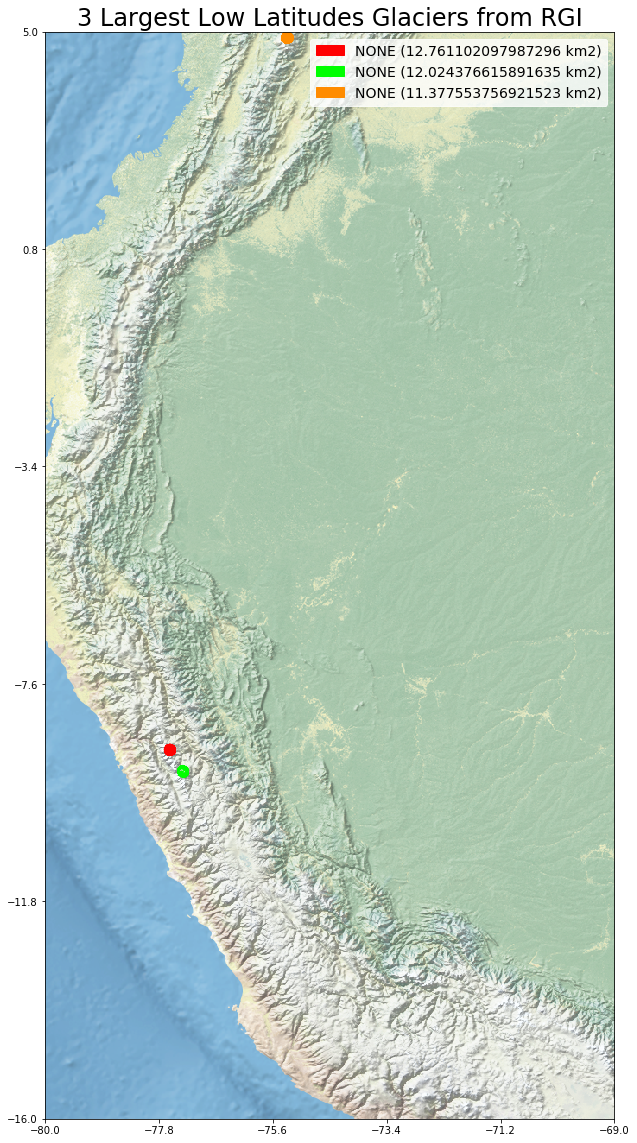

In [14]:
# Plot 3 largest glaciers on natural earth from RGI
legend_colors = ['red', 'lime', 'darkorange', 'purple']
legend_labels = [rgi_glaciers_df['Name'][0] + ' (' + str(rgi_glaciers_df['Area'][0]) + ' km2)',
                 rgi_glaciers_df['Name'][1] + ' (' + str(rgi_glaciers_df['Area'][1]) + ' km2)',
                 rgi_glaciers_df['Name'][2] + ' (' + str(rgi_glaciers_df['Area'][2]) + ' km2)']
                 #rgi_glaciers_df['Name'][3] + ' (' + str(rgi_glaciers_df['Area'][3]) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
# Zoom
minx = -80
maxx = -69
miny = -16
maxy = 5
#Zoom to specific glacier
#minx, miny, maxx, maxy = rgi_glaciers_df.iloc[2:3].total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from rgi dataframe
rgi_glaciers_df.iloc[0:1].boundary.plot(ax=ax, color='red', linewidth=10)
rgi_glaciers_df.iloc[1:2].boundary.plot(ax=ax, color='lime', linewidth=10)
rgi_glaciers_df.iloc[2:3].boundary.plot(ax=ax, color='darkorange', linewidth=10)
#rgi_glaciers_df.iloc[3:4].boundary.plot(ax=ax, color='purple', linewidth=10)
#rgi_glaciers_df.iloc[4:5].boundary.plot(ax=ax, color='darkgreen', linewidth=10)
ax.set_title('3 Largest ' + region_name + ' Glaciers from RGI', fontsize=24)
# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

showticks = 1
if showticks == 1:
    ax.set_axis_on()
    # Create evenly spaced x-axis and y-axis tick marks
    xtick1 = minx+((maxx-minx)/5*1)
    xtick2 = minx+((maxx-minx)/5*2)
    xtick3 = minx+((maxx-minx)/5*3)
    xtick4 = minx+((maxx-minx)/5*4)
    ytick1 = miny+((maxy-miny)/5*1)
    ytick2 = miny+((maxy-miny)/5*2)
    ytick3 = miny+((maxy-miny)/5*3)
    ytick4 = miny+((maxy-miny)/5*4)
    ax.set_xticks([minx, xtick1, xtick2, xtick3, xtick4, maxx])
    ax.set_yticks([miny, ytick1, ytick2, ytick3, ytick4, maxy])
plt.show()

## Compare Glaciers from GLIMS and RGI
Do they match? If yes, continue, if no, stop notebook and investigate

In [15]:
if (glims_glaciers_df['glac_name'][0] == rgi_glaciers_df['Name'][0] and 
    glims_glaciers_df['glac_name'][1] == rgi_glaciers_df['Name'][1] and 
    glims_glaciers_df['glac_name'][2] == rgi_glaciers_df['Name'][2]):
    print("They match!")
else:
    if handled != 1:
        # If this hasn't been handled, stop execution
        class StopExecution(Exception):
            def _render_traceback_(self):
                pass

        print("They do NOT Match! Stopping notebook.")
        raise StopExecution
    else:
        # If this has been handled, continue execution
        print("They do not match but this has been handled in the code below this section, so continue.")

They do NOT Match! Stopping notebook.


## Create final shapefiles
This section creates and formats the final dataframe, plots it to make sure it looks ok, and saves it to a shapefile.

Top 3 for V2:
1. Pucca Orcco (G289157E13939S), 12.36, 2016-01-16
2. NONE (G284682E04880N), 11.38, 2000-06-15
3. NONE (G282507E09263S), 10.92, 2016-01-16

Details on the comparison of V2 (GLIMS 2025 and RGI 7) and V1:

* For V2 (GLIMS 20250603 and RGI 7), not much matches V1, nor do they really match each other.
* The only glacier that is the same in the top 3 between GLIMS 2025 and V1 is Pucca Orcco (G289157E13939S). It 1st in GLIMS 2025 and 2nd in V1. It does not appear at all in top 5 of RGI 7.
* The only other similarity is for Japupunta, which is 4th in GLIMS 2025 and 3rd in V1. It does not appear at all in top 5 of RGI 7.
* 2nd largest in GLIMS 2025 matches 3rd largest in RGI 7 (G284682E04880N). They have the same date and area.
* All the observation dates for GLIMS 2025 are much newer than RGI 7. Will use GLIMS 2025 alone for this region for V2 glaciers.

Since there are no names for these glaciers in GLIMS or RGI, need to find them or set them.

For #2, going with the name Nevado del Ruiz Glacier from the volcano that this glacier sits on and from Satellite Image Atlas of Glaciers of the World: South America.

For #3, this glacier is in the Cordillera Blanca of Peru on the Nevado Copa mountain. Will call it Nevado Copa glacier.

### Create final dataframe

In [16]:
# Clean up glims_glaciers_df - drop uneeded rows and reset index
glims_glaciers_df.drop([3,4], inplace = True)
glims_glaciers_df = glims_glaciers_df.reset_index(drop=True)

# Set up the final dataframe that will be used when saving the final shapefiles
# Drop columns that are not needed for the final data (use GLIMS dataframe for this)
final_glacier_data_df = glims_glaciers_df.drop(['area', 'width', 'length', 
                                        'min_elev', 'mean_elev', 'max_elev'], axis=1)

# Add region_name column
final_glacier_data_df['reg_name'] = region_name

# Rename some columns
final_glacier_data_df.rename(columns={'glac_id': 'glims_id', 'db_area': 'area_km2', 
                                       'src_date': 'date'}, inplace=True)

# Add RGI ID column
final_glacier_data_df['rgi_id'] = ('RGI2000-v7.0-G-16-02325', 'RGI2000-v7.0-G-16-00050', 'RGI2000-v7.0-G-16-00423')

# Add area_src column that gets filled lower down
final_glacier_data_df['area_src'] = '-999'

# Reorder the columns of the dataframe
final_glacier_data_df = final_glacier_data_df[['region_no', 'reg_name', 'glac_name', 'glims_id', 'rgi_id', 
                                               'area_km2', 'area_src', 'date', 'geometry']]

In [17]:
final_glacier_data_df

,region_no,reg_name,glac_name,glims_id,rgi_id,area_km2,area_src,date,geometry
0,16,Low Latitudes,None,G289157E13939S,RGI2000-v7.0-G-16-02325,12.3644,-999,2016-01-16T00:00:00,"POLYGON ((-70.864193 -13.97191, -70.865734 -13..."
1,16,Low Latitudes,None,G284682E04880N,RGI2000-v7.0-G-16-00050,11.3776,-999,2000-06-15T00:00:00,"POLYGON ((-75.331776 4.891184, -75.33204600000..."
2,16,Low Latitudes,None,G282507E09263S,RGI2000-v7.0-G-16-00423,10.9248,-999,2016-01-16T00:00:00,"POLYGON ((-77.518326 -9.259943, -77.518216 -9...."


In [18]:
# Calculate area and update dataframe as neccessary and clean the date format in the date column
# If GLIMS and RGI dates are the same year, then average the two areas.
# If GLIMS date is more recent, then use that average.
# If RGI date is more recent, then use that average. (Note I don't think this ever happens)
# Note only comparing by year because sometimes the month and day are not known. Year matching is close enough.
for x in range(3):
    print(x)
    
    if x != 0: # Need to skip the first GLIMS one since there's no match in RGI and GLIMS 2 and 3 match RGI 1 and 2
        
        # Exract and clean GLIMS date so that it is comparable to RGI date
        glims_date = glims_glaciers_df['src_date'][x][0:10].replace('-', '')
        glims_year = glims_date[0:4]
        print('glims date: ' + glims_date)
        #print('glims year: ' + glims_year)
    
        # Extract RGI date
        rgi_date = rgi_glaciers_df['BgnDate'][x-1]
        rgi_year = rgi_date[0:4]
        print('rgi date: ' + rgi_date)
        #print('rgi year: ' + rgi_year)
    
        
        if glims_year == rgi_year:
            # Average GLIMS and RGI areas
            area = np.average([glims_glaciers_df['db_area'][x], rgi_glaciers_df['Area'][x-1]])
            area_src = 'A'
            print('Averaging area: ' + str(area))
        elif glims_year > rgi_year:
            # Use GLIMS area for the area
            area = glims_glaciers_df['db_area'][x]
            area_src = 'G'
            print('Using GLIMS area: ' + str(area))
        elif rgi_year > glims_year:
            # Use RGI area for the area
            area = rgi_glaciers_df['Area'][x-1]
            area_src = 'R'
            print('Using RGI area: ' + str(area))
        else:
            print("Error. Area could not be calculated.")
            
    else:
        # Use GLIMS area for the area
        area = glims_glaciers_df['db_area'][x]
        area_src = 'G'
        print('Using GLIMS area: ' + str(area))
    
    print('')
    # Set the area in the final dataframe
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('area_km2')] = area
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('area_src')] = area_src
    
    # Clean the date format in the final dataframe
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('date')] = glims_glaciers_df['src_date'][x][0:10]
    
# Clean up glacier names
final_glacier_data_df.iloc[0, final_glacier_data_df.columns.get_loc('glac_name')] = "Pucca Orcco Glacier"
final_glacier_data_df.iloc[1, final_glacier_data_df.columns.get_loc('glac_name')] = "Nevado del Ruiz Glacier"
final_glacier_data_df.iloc[2, final_glacier_data_df.columns.get_loc('glac_name')] = "Nevado Copa glacier"

0
Using GLIMS area: 12.3644

1
glims date: 20000615
rgi date: 1998-09-02T00:00:00
Using GLIMS area: 11.3776

2
glims date: 20160116
rgi date: 1998-09-02T00:00:00
Using GLIMS area: 10.9248



In [19]:
# Find the centroid of the glacier and add the lat/lon to the dataframe
centroidseries_gl = final_glacier_data_df['geometry'].centroid
    
final_glacier_data_df['cenlat'] = [centroidseries_gl.geometry.y[0], centroidseries_gl.geometry.y[1], 
                                   centroidseries_gl.geometry.y[2]]
final_glacier_data_df['cenlon'] = [centroidseries_gl.geometry.x[0], centroidseries_gl.geometry.x[1], 
                                   centroidseries_gl.geometry.x[2]]

# Reorder the columns of the dataframe
final_glacier_data_df = final_glacier_data_df[['region_no', 'reg_name', 'glac_name', 'glims_id', 'rgi_id', 
                                               'area_km2', 'area_src', 'date', 'cenlat', 'cenlon', 'geometry']]

In [ ]:
# Because only using the GLIMS data for Jancapampa, set the RGI ID to N/A
#final_glacier_data_df.iloc[0, final_glacier_data_df.columns.get_loc('rgi_id')] = 'N/A'

In [20]:
final_glacier_data_df

,region_no,reg_name,glac_name,glims_id,rgi_id,area_km2,area_src,date,cenlat,cenlon,geometry
0,16,Low Latitudes,Pucca Orcco Glacier,G289157E13939S,RGI2000-v7.0-G-16-02325,12.3644,G,2016-01-16,-13.939044,-70.841300,"POLYGON ((-70.864193 -13.97191, -70.865734 -13..."
1,16,Low Latitudes,Nevado del Ruiz Glacier,G284682E04880N,RGI2000-v7.0-G-16-00050,11.3776,G,2000-06-15,4.880098,-75.317744,"POLYGON ((-75.331776 4.891184, -75.33204600000..."
2,16,Low Latitudes,Nevado Copa glacier,G282507E09263S,RGI2000-v7.0-G-16-00423,10.9248,G,2016-01-16,-9.264361,-77.501025,"POLYGON ((-77.518326 -9.259943, -77.518216 -9...."


### Plot final dataframe to check accuracy

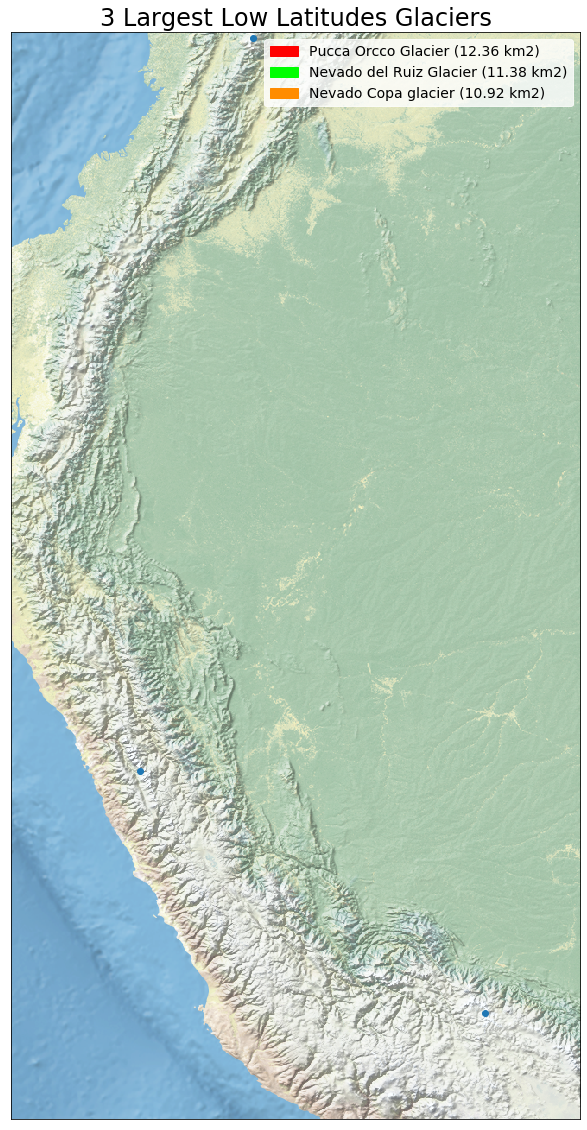

In [21]:
# Check that the geodataframe wasn't corrupted from these changes by plotting the data
# Plot 3 largest glaciers on natural earth from GLIMS
# Set up legend. Note that the sizes come from an average of GLIMS and RGI. 
# See wgms-glacier-project/data/comparison/compare-glims-rgi.xlsx
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [final_glacier_data_df['glac_name'][0] + ' (' + str(round(final_glacier_data_df['area_km2'][0], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][1] + ' (' + str(round(final_glacier_data_df['area_km2'][1], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][2] + ' (' + str(round(final_glacier_data_df['area_km2'][2], 2)) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
# Zoom
#minx = -73
#maxx = -67
#miny = -16
#maxy = -12
minx = -80
maxx = -69
miny = -16
maxy = 5
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from glims dataframe
final_glacier_data_df.iloc[0:1].plot(ax=ax, color='red')
final_glacier_data_df.iloc[1:2].plot(ax=ax, color='lime')
final_glacier_data_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest ' + region_name + ' Glaciers', fontsize=24)

# Plot the center points of the glacier complexes
centroidseries_gl.plot(ax=ax)

# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

### Create shapefile from the final dataframe

In [22]:
# Write dataframe to shapefile and save to zip if it doesn't already exist
glacier_zipfile_fn = "data/final-dataset/version-" + str(final_version) + "/region-" + \
                     region_number + "-largest-glaciers.zip"
if os.path.exists(glacier_zipfile_fn) == False:
    # Create the shapefile
    final_glacier_data_fn = "data/final-dataset/version-" + str(final_version) + "/region-" + region_number + \
                    "-largest-glaciers.shp"
    final_glacier_data_df.to_file(driver='ESRI Shapefile', filename=final_glacier_data_fn)
    
    # Zip up the shapefile
    glacier_zipfile_fn = ws.zipshp(final_glacier_data_fn, Delete=True)
    print("Creating zipfile: " + glacier_zipfile_fn)
else:
    print(glacier_zipfile_fn + " already extists")

Creating zipfile: data/final-dataset/version-2\region-16-largest-glaciers.zip


# * * * * * * * * Ice Cap Analysis * * * * * * * *

In [ ]:
# Set flag run_icecap to 1 when you are ready to run the ice cap analysis. If it's not 1, stop the notebook
# This stop allows you to just run the whole notebook when you are still working on the glacier analysis
run_icecap = 0
if run_icecap != 1:
    # If this hasn't been handled, stop execution
    class StopExecution(Exception):
        def _render_traceback_(self):
            pass
    print("Not ready to run ice cap analysis. Stopping notebook.")
    raise StopExecution

In [ ]:
# Open this regions ice caps from the exploded version
ice_caps_ex_fn = "data/glims/processed/ice-caps/largest/largest-ice-caps-region_" + region_number + "_laea.shp"
ice_caps_ex_df = gpd.read_file(ice_caps_ex_fn)

In [ ]:
ice_caps_ex_df

In [ ]:
# Plot this regions ice caps in one frame
# Set up legend
legend_colors = ['darkorange', 'red', 'blue', 'purple', 'pink', 'yellow', 'green', 'cyan', 'magenta', 'lime']
legend_labels = [str(ice_caps_ex_df['id'][0]) + ' ' + str(round(ice_caps_ex_df['area'][0])), 
                 str(ice_caps_ex_df['id'][1]) + ' ' + str(round(ice_caps_ex_df['area'][1])), 
                 str(ice_caps_ex_df['id'][2]) + ' ' + str(round(ice_caps_ex_df['area'][2])), 
                 str(ice_caps_ex_df['id'][3]) + ' ' + str(round(ice_caps_ex_df['area'][3])),
                 str(ice_caps_ex_df['id'][4]) + ' ' + str(round(ice_caps_ex_df['area'][4])),
                 str(ice_caps_ex_df['id'][5]) + ' ' + str(round(ice_caps_ex_df['area'][5])),
                 str(ice_caps_ex_df['id'][6]) + ' ' + str(round(ice_caps_ex_df['area'][6])),
                 str(ice_caps_ex_df['id'][7]) + ' ' + str(round(ice_caps_ex_df['area'][7])),
                 str(ice_caps_ex_df['id'][8]) + ' ' + str(round(ice_caps_ex_df['area'][8])),
                 str(ice_caps_ex_df['id'][9]) + ' ' + str(round(ice_caps_ex_df['area'][9]))]
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot largest
ice_caps_ex_df.iloc[0:1].plot(ax=ax, color="darkorange")
ice_caps_ex_df.iloc[1:2].plot(ax=ax, color="red")
ice_caps_ex_df.iloc[2:3].plot(ax=ax, color="blue")
ice_caps_ex_df.iloc[3:4].plot(ax=ax, color="purple")
ice_caps_ex_df.iloc[4:5].plot(ax=ax, color="pink")
ice_caps_ex_df.iloc[5:6].plot(ax=ax, color="yellow")
ice_caps_ex_df.iloc[6:7].plot(ax=ax, color="green")
ice_caps_ex_df.iloc[7:8].plot(ax=ax, color="cyan")
ice_caps_ex_df.iloc[8:9].plot(ax=ax, color="magenta")
ice_caps_ex_df.iloc[9:10].plot(ax=ax, color="lime")
ax.set_title('Largest ' + region_name + ' Ice Caps/Icefields', fontsize=24)
ax.set_axis_off()

# Add legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

## Create Final Ice Catchment Data Frame

This ice catchment data frame will then be saved to a shapefile.

In [ ]:
# Update and reorganize ice_caps_ex_df to create final df
# Drop uneeded columns
final_catchment_data_df = ice_caps_ex_df.drop(['id'], axis=1)

# Keepthe top 3 ice caps/icefields
final_catchment_data_df.drop([3, 4, 5, 6, 7, 8, 9], inplace = True)

# Add region_no column
final_catchment_data_df['region_no'] = region_number

# Add region_name column
final_catchment_data_df['reg_name'] = region_name

# Add catchment names
final_catchment_data_df['ic_name'] = ['Vilcanota Glacier Complex', 
                                      'Chaupi Orco-Soral Glacier Complex',
                                      'Ancohuma Glacier Complex'] 

### Get ice catchment GLIMS IDs and measurement dates from a range of glacier outline dates.

In [ ]:
# Open GLIMS shapefile with all of the glacier outlines
glims_all_glaciers_fn = "data/glims/processed/cleaned/glims_region_" + region_number + "_cleaned.shp"
glims_all_glaciers_df = gpd.read_file(glims_all_glaciers_fn)

In [ ]:
# The call to the pip function can take a couple of minutes to many hours to run depending on the complexity and size
# of the ice catchment outline. I set up the code to save the output to shapefiles that can be read in more quickly
# if desired. However, you can toggle whether you read the files or run the pip command with the following variable.
# Note that you must run the pip command the first time this code is run in order to create the shapefiles.
run_code = 0 # set to 0 to read from shapefiles, set to 1 to run pip command

# Get glaciers in the 1st largest glacier complex
if run_code == 1: # run pip command
    largest_ic_1_mask = ws.pip(glims_all_glaciers_df, ice_caps_ex_df.iloc[0:1].reset_index(drop=True))
    largest_ic_1_glaciers = glims_all_glaciers_df.loc[largest_ic_1_mask]
    largest_ic_1_glaciers.reset_index(drop=True, inplace=True)
elif run_code == 0: # read saved shapefiles
    ic_1_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                        region_number + "-1st-largest-ic-glacier-outlines.zip"
    with zipfile.ZipFile(ic_1_glaciers_zfn,"r") as zip_ref:
        zip_ref.extractall("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped")

    ic_1_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/region-" + \
                                  region_number + "-1st-largest-ic-glacier-outlines.shp"
    largest_ic_1_glaciers = gpd.read_file(ic_1_glaciers_shape_fn)
    print("Reading file " + ic_1_glaciers_shape_fn)

    # Clean up unzipped files to save disk space
    filelist = glob.glob("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/*")
    for f in filelist:
        os.remove(f)
else:
    print("Incorrect value for the run_code variable. Must be 0 or 1.")

# Clean and print the minimum date and the maximum date
largest_ic_1_min_date = largest_ic_1_glaciers['src_date'].min()[0:10]
largest_ic_1_max_date = largest_ic_1_glaciers['src_date'].max()[0:10]
print('1st largest start date: ' + largest_ic_1_min_date)
print('1st largest end date: ' + largest_ic_1_max_date)
print('')

# Get all glims ids that make up the 1st largest ice catchment
largest_ic_1_glims_ids = largest_ic_1_glaciers['glac_id']
for i in range(len(largest_ic_1_glims_ids)):
    if i == 0:
        all_largest_ic_1_ids = largest_ic_1_glims_ids[i]
    else:
        all_largest_ic_1_ids = all_largest_ic_1_ids + ', ' + largest_ic_1_glims_ids[i]

# Get glaciers in the 2nd largest glacier complex
if run_code == 1: # run pip command
    largest_ic_2_mask = ws.pip(glims_all_glaciers_df, ice_caps_ex_df.iloc[1:2].reset_index(drop=True))
    largest_ic_2_glaciers = glims_all_glaciers_df.loc[largest_ic_2_mask]
    largest_ic_2_glaciers.reset_index(drop=True, inplace=True)
elif run_code == 0: # read saved shapefiles
    ic_2_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                        region_number + "-2nd-largest-ic-glacier-outlines.zip"
    with zipfile.ZipFile(ic_2_glaciers_zfn,"r") as zip_ref:
        zip_ref.extractall("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped")

    ic_2_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/region-" + \
                                  region_number + "-2nd-largest-ic-glacier-outlines.shp"
    largest_ic_2_glaciers = gpd.read_file(ic_2_glaciers_shape_fn)
    print("Reading file " + ic_2_glaciers_shape_fn)

    # Clean up unzipped files to save disk space
    filelist = glob.glob("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/*")
    for f in filelist:
        os.remove(f)
else:
    print("Incorrect value for the run_code variable. Must be 0 or 1.")

# Clean and print the minimum date and the maximum date
largest_ic_2_min_date = largest_ic_2_glaciers['src_date'].min()[0:10]
largest_ic_2_max_date = largest_ic_2_glaciers['src_date'].max()[0:10]
print('2nd largest start date: ' + largest_ic_2_min_date)
print('2nd largest end date: ' + largest_ic_2_max_date)
print('')

# Get all glims ids that make up the 2nd largest ice catchment
largest_ic_2_glims_ids = largest_ic_2_glaciers['glac_id']
for i in range(len(largest_ic_2_glims_ids)):
    if i == 0:
        all_largest_ic_2_ids = largest_ic_2_glims_ids[i]
    else:
        all_largest_ic_2_ids = all_largest_ic_2_ids + ', ' + largest_ic_2_glims_ids[i]


# Get glaciers in the 3rd largest glacier complex
if run_code == 1: # run pip command
    largest_ic_3_mask = ws.pip(glims_all_glaciers_df, ice_caps_ex_df.iloc[2:3].reset_index(drop=True))
    largest_ic_3_glaciers = glims_all_glaciers_df.loc[largest_ic_3_mask]
    largest_ic_3_glaciers.reset_index(drop=True, inplace=True)
elif run_code == 0: # read saved shapefiles
    ic_3_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                        region_number + "-3rd-largest-ic-glacier-outlines.zip"
    with zipfile.ZipFile(ic_3_glaciers_zfn,"r") as zip_ref:
        zip_ref.extractall("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped")

    ic_3_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/region-" + \
                                  region_number + "-3rd-largest-ic-glacier-outlines.shp"
    largest_ic_3_glaciers = gpd.read_file(ic_3_glaciers_shape_fn)
    print("Reading file " + ic_3_glaciers_shape_fn)

    # Clean up unzipped files to save disk space
    filelist = glob.glob("data/glims/processed/ice-caps/largest/individual-glacier-outlines/unzipped/*")
    for f in filelist:
        os.remove(f)
else:
    print("Incorrect value for the run_code variable. Must be 0 or 1.")

# Clean and print the minimum date and the maximum date
largest_ic_3_min_date = largest_ic_3_glaciers['src_date'].min()[0:10]
largest_ic_3_max_date = largest_ic_3_glaciers['src_date'].max()[0:10]
print('3rd largest start date: ' + largest_ic_3_min_date)
print('3rd largest end date: ' + largest_ic_3_max_date)
print('')

# Get all glims ids that make up the 3rd largest ice catchment
largest_ic_3_glims_ids = largest_ic_3_glaciers['glac_id']
for i in range(len(largest_ic_3_glims_ids)):
    if i == 0:
        all_largest_ic_3_ids = largest_ic_3_glims_ids[i]
    else:
        all_largest_ic_3_ids = all_largest_ic_3_ids + ', ' + largest_ic_3_glims_ids[i]

In [ ]:
# Find the centroid of the glacier complex and add the lat/lon to the dataframe
centroidseries = final_catchment_data_df['geometry'].centroid

In [ ]:
# Add the dates to the dataframe
final_catchment_data_df['min_date'] = [largest_ic_1_min_date, largest_ic_2_min_date, largest_ic_3_min_date]

final_catchment_data_df['max_date'] = [largest_ic_1_max_date, largest_ic_2_max_date, largest_ic_3_max_date]

# Add lat/lon
final_catchment_data_df['cenlat'] = [centroidseries.geometry.y[0], centroidseries.geometry.y[1], 
                                     centroidseries.geometry.y[2]]
final_catchment_data_df['cenlon'] = [centroidseries.geometry.x[0], centroidseries.geometry.x[1], 
                                     centroidseries.geometry.x[2]]

# Reorder the columns
final_catchment_data_df = final_catchment_data_df[['region_no', 'reg_name', 'ic_name', 'area', 
                                                   'min_date', 'max_date', 'cenlat', 'cenlon', 'geometry']]
# Rename the area column
final_catchment_data_df.rename(columns={'area': 'area_km2'}, inplace=True)
                                     
# Reset index
final_catchment_data_df = final_catchment_data_df.reset_index(drop=True)

In [ ]:
final_catchment_data_df

### Plot the final catchment dataframe to verify it looks correct

In [ ]:
# Plot this regions ice caps in one frame
# Set up legend
legend_colors = ['red', 'lime', 'darkorange'] #, 'purple', 'pink', 'yellow']
legend_labels = [final_catchment_data_df['ic_name'][0] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][0], 2)) + ' km2)', 
                 final_catchment_data_df['ic_name'][1] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][1], 2)) + ' km2)', 
                 final_catchment_data_df['ic_name'][2] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][2], 2)) + ' km2)'] 
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = region_outline.total_bounds
# Zoom
minx = -73
maxx = -67
miny = -16
maxy = -12
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot largest
final_catchment_data_df.iloc[0:1].plot(ax=ax, color="red")
final_catchment_data_df.iloc[1:2].plot(ax=ax, color="lime")
final_catchment_data_df.iloc[2:3].plot(ax=ax, color="darkorange")
ax.set_title('Largest ' + region_name + ' Glacier Complexes', fontsize=24)
ax.set_axis_off()

# Plot the center points of the glacier complexes
centroidseries.plot(ax=ax)

# Add legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

### Save final catchment dataframe to a shapefile

In [ ]:
# Write dataframe to shapefile and save to zip if it doesn't already exist
catchment_zipfile_fn = "data/final-dataset/region-" + region_number + "-largest-complexes.zip"
if os.path.exists(catchment_zipfile_fn) == False:
    # Create the shapefile
    final_catchment_data_fn = "data/final-dataset/region-" + region_number + "-largest-complexes.shp"
    final_catchment_data_df.to_file(driver='ESRI Shapefile', filename=final_catchment_data_fn)
    
    # Zip up the shapefile
    catchment_zipfile_fn = ws.zipshp(final_catchment_data_fn, Delete=True)
    print("Creating zipfile: " + catchment_zipfile_fn)
else:
    print(catchment_zipfile_fn + " already extists")

In [ ]:
# Save the glims ids to a text file because the text is too long to be saved to a shapefile
text_file_1st_fn = "data/final-dataset/region-" + region_number + "-1st-largest-glims-ids.txt"
if os.path.exists(text_file_1st_fn) == False:
    print("Creating text file: " + text_file_1st_fn)
    text_file = open(text_file_1st_fn, "w")
    n = text_file.write(all_largest_ic_1_ids)
    text_file.close()
else:
    print(text_file_1st_fn + " already extists")
    
text_file_2nd_fn = "data/final-dataset/region-" + region_number + "-2nd-largest-glims-ids.txt"
if os.path.exists(text_file_2nd_fn) == False:
    print("Creating text file: " + text_file_2nd_fn)
    text_file = open(text_file_2nd_fn, "w")
    n = text_file.write(all_largest_ic_2_ids)
    text_file.close()
else:
    print(text_file_2nd_fn + " already extists")
    
text_file_3rd_fn = "data/final-dataset/region-" + region_number + "-3rd-largest-glims-ids.txt"
if os.path.exists(text_file_3rd_fn) == False:
    print("Creating text file: " + text_file_3rd_fn)
    text_file = open(text_file_3rd_fn, "w")
    n = text_file.write(all_largest_ic_3_ids)
    text_file.close()
else:
    print(text_file_3rd_fn + " already extists")
    
# Save the glacier outline dataframes from the pip command to shapefiles for easier recall later because sometimes
# the pip command can take hours to run
ic_1_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                    region_number + "-1st-largest-ic-glacier-outlines.zip"
if os.path.exists(ic_1_glaciers_zfn) == False:
    # Create the shapefile
    ic_1_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                              region_number + "-1st-largest-ic-glacier-outlines.shp"
    largest_ic_1_glaciers.to_file(driver='ESRI Shapefile', filename=ic_1_glaciers_shape_fn)
    
    # Zip up the shapefile
    ic_1_glaciers_zfn = ws.zipshp(ic_1_glaciers_shape_fn, Delete=True)
    print("Creating zipfile: " + ic_1_glaciers_zfn)
else:
    print(ic_1_glaciers_zfn + " already extists")
    
ic_2_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                    region_number + "-2nd-largest-ic-glacier-outlines.zip"
if os.path.exists(ic_2_glaciers_zfn) == False:
    # Create the shapefile
    ic_2_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                              region_number + "-2nd-largest-ic-glacier-outlines.shp"
    largest_ic_2_glaciers.to_file(driver='ESRI Shapefile', filename=ic_2_glaciers_shape_fn)
    
    # Zip up the shapefile
    ic_2_glaciers_zfn = ws.zipshp(ic_2_glaciers_shape_fn, Delete=True)
    print("Creating zipfile: " + ic_2_glaciers_zfn)
else:
    print(ic_2_glaciers_zfn + " already extists")
    
ic_3_glaciers_zfn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                    region_number + "-3rd-largest-ic-glacier-outlines.zip"
if os.path.exists(ic_3_glaciers_zfn) == False:
    # Create the shapefile
    ic_3_glaciers_shape_fn = "data/glims/processed/ice-caps/largest/individual-glacier-outlines/region-" + \
                              region_number + "-3rd-largest-ic-glacier-outlines.shp"
    largest_ic_3_glaciers.to_file(driver='ESRI Shapefile', filename=ic_3_glaciers_shape_fn)
    
    # Zip up the shapefile
    ic_3_glaciers_zfn = ws.zipshp(ic_3_glaciers_shape_fn, Delete=True)
    print("Creating zipfile: " + ic_3_glaciers_zfn)
else:
    print(ic_3_glaciers_zfn + " already extists")

### Extra Stuff: Checking if pip function needs a buffer
Due to tiny differences in vertices computed from the explode method used to find ice catchments, the pip function doesn't always return all glaceris that should be in that outline. This section analyses what size buffer is needed to capture all glacier outlines that reside in an ice catchment outline.

After perporming the analysis below, no buffer adjustment needed for Region 16.

In [ ]:
# Stop execution here. Run extra stuff manually if you want to run this code
class StopExecution(Exception):
    def _render_traceback_(self):
        pass

print("Stopping notebook.")
raise StopExecution

#### Check 1st largest

In [ ]:
# Plot the catchment outline
final_catchment_data_df.iloc[0:1].boundary.plot()

# Plot the outlines acquired from pip function
largest_ic_1_glaciers.boundary.plot()

# Compare area calculated from the catchment outline and the sum of the individual outlines acquired from pip function
print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[0:1][0])
print('Area from sum: ', largest_ic_1_glaciers['db_area'].sum())

# Calculate the difference and print a message based on the magnitude of the difference
area_diff_1 = final_catchment_data_df['area_km2'].iloc[0:1][0] - largest_ic_1_glaciers['db_area'].sum()
if (abs(area_diff_1)) <= .001:
    print("Areas match well! Area difference: ", abs(area_diff_1))
    match1 = 1
else:
    print("*** Areas do not match well. May need to add a buffer. Area difference:", abs(area_diff_1))
    match1 = 0

In [ ]:
# If the areas do not match need to try different buffer values to get best match
buffer_val = 0
if match1 == 0:
    # Trying a buffer on the within function to see if it captures more of the galcier outliness
    ic_1_explode_outline = ice_caps_ex_df.iloc[0:1].reset_index(drop=True)
    largest_ic_1_mask_test = glims_all_glaciers_df.buffer(0).within(ic_1_explode_outline.loc[0, 'geometry'].
                                                                    buffer(buffer_val))
    largest_ic_1_glaciers_test = glims_all_glaciers_df.loc[largest_ic_1_mask_test]
    largest_ic_1_glaciers_test.reset_index(drop=True, inplace=True)
    
    # Plot the new buffered glacier outlines
    largest_ic_1_glaciers_test.boundary.plot()
    
    # Compare area calculated from the catchment outline and the sum of the individual outlines 
    # acquired from pip function
    print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[0:1][0])
    print('Area from sum: ', largest_ic_1_glaciers_test['db_area'].sum())
    
    # Plot the new buffered glacier outlines against the ice catchment outline
    fig, ax = plt.subplots(figsize=(5, 5))
    largest_ic_1_glaciers_test.boundary.plot(ax=ax, color='red')
    final_catchment_data_df.iloc[0:1].boundary.plot(ax=ax, color='blue')

#### Check 2nd largest

In [ ]:
# Plot the catchment outline
final_catchment_data_df.iloc[1:2].boundary.plot()

# Plot the outlines acquired from pip function
largest_ic_2_glaciers.boundary.plot()

# Compare area calculated from the catchment outline and the sum of the individual outlines acquired from pip function
print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[1:2][1])
print('Area from sum: ', largest_ic_2_glaciers['db_area'].sum())

# Calculate the difference and print a message based on the magnitude of the difference
area_diff_2 = final_catchment_data_df['area_km2'].iloc[1:2][1] - largest_ic_2_glaciers['db_area'].sum()
if (abs(area_diff_2)) <= .001:
    print("Areas match well! Area difference: ", abs(area_diff_2))
    match2 = 1
else:
    print("*** Areas do not match well. May need to add a buffer. Area difference:", abs(area_diff_2))
    match2 = 0

In [ ]:
# If the areas do not match need to try different buffer values to get best match
buffer_val = 0
if match2 == 0:
    # Trying a buffer on the within function to see if it captures more of the galcier outliness
    ic_2_explode_outline = ice_caps_ex_df.iloc[1:2].reset_index(drop=True)
    largest_ic_2_mask_test = glims_all_glaciers_df.buffer(0).within(ic_2_explode_outline.loc[0, 'geometry'].
                                                                    buffer(buffer_val))
    largest_ic_2_glaciers_test = glims_all_glaciers_df.loc[largest_ic_2_mask_test]
    largest_ic_2_glaciers_test.reset_index(drop=True, inplace=True)
    
    # Plot the new buffered glacier outlines
    largest_ic_2_glaciers_test.boundary.plot()
    
    # Compare area calculated from the catchment outline and the sum of the individual outlines 
    #acquired from pip function
    print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[1:2][1])
    print('Area from sum: ', largest_ic_2_glaciers_test['db_area'].sum())
    
    # Plot the new buffered glacier outlines against the ice catchment outline
    fig, ax = plt.subplots(figsize=(5, 5))
    largest_ic_2_glaciers_test.boundary.plot(ax=ax, color='red')
    final_catchment_data_df.iloc[1:2].boundary.plot(ax=ax, color='blue')

#### Check 3rd largest

In [ ]:
# Plot the catchment outline
final_catchment_data_df.iloc[2:3].boundary.plot()

# Plot the outlines acquired from pip function
largest_ic_3_glaciers.boundary.plot()

# Compare area calculated from the catchment outline and the sum of the individual outlines 
# acquired from pip function
print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[2:3][2])
print('Area from sum: ', largest_ic_3_glaciers['db_area'].sum())

# Calculate the difference and print a message based on the magnitude of the difference
area_diff_3 = final_catchment_data_df['area_km2'].iloc[2:3][2] - largest_ic_3_glaciers['db_area'].sum()
if (abs(area_diff_3)) <= .001:
    print("Areas match well! Area difference: ", abs(area_diff_3))
    match3 = 1
else:
    print("*** Areas do not match well. May need to add a buffer. Area difference:", abs(area_diff_3))
    match3 = 0

In [ ]:
# If the areas do not match need to try different buffer values to get best match
buffer_val = 0
if match3 == 0:
    # Trying a buffer on the within function to see if it captures more of the galcier outliness
    ic_3_explode_outline = ice_caps_ex_df.iloc[2:3].reset_index(drop=True)
    largest_ic_3_mask_test = glims_all_glaciers_df.buffer(0).within(ic_3_explode_outline.loc[0, 'geometry'].
                                                                    buffer(buffer_val))
    largest_ic_3_glaciers_test = glims_all_glaciers_df.loc[largest_ic_3_mask_test]
    largest_ic_3_glaciers_test.reset_index(drop=True, inplace=True)
    
    # Plot the new buffered glacier outlines
    largest_ic_3_glaciers_test.boundary.plot()
    
    # Compare area calculated from the catchment outline and the sum of the individual outlines 
    # acquired from pip function
    print('Area from catchment outline: ', final_catchment_data_df['area_km2'].iloc[2:3][2])
    print('Area from sum: ', largest_ic_3_glaciers_test['db_area'].sum())
    
    # Plot the new buffered glacier outlines against the ice catchment outline
    fig, ax = plt.subplots(figsize=(5, 5))
    largest_ic_3_glaciers_test.boundary.plot(ax=ax, color='red')
    final_catchment_data_df.iloc[2:3].boundary.plot(ax=ax, color='blue')

# Extra/Old stuff

The last ice cap in the list (ID 95) is Quelccaya ice cap. Ask Michael if he thinks I should do an ice cap analysis of this region.

In [ ]:
# Stop execution here. Run extra stuff manually if you want to run this code
class StopExecution(Exception):
    def _render_traceback_(self):
        pass

print("Stopping notebook.")
raise StopExecution

In [ ]:
# Open this regions ice caps from the exploded version
# Note ic_epsg is no longer defined
ice_caps_ex_fn = "data/glims/processed/ice-caps/largest/largest-ice-caps-region_" + \
                  region_number + "_esri" + ic_epsg + ".shp"
ice_caps_ex_df = gpd.read_file(ice_caps_ex_fn)

In [ ]:
ice_caps_ex_df

In [ ]:
# Plot this regions ice caps in one frame
# Set up legend
#legend_colors = ['darkorange', 'red', 'blue', 'purple', 'pink', 'yellow', 'green', 'cyan', 'magenta', 'lime',
#                 'deepskyblue', 'forestgreen', 'gold', 'lightseagreen', 'navy']
legend_colors = ['lime', 'forestgreen']
legend_labels = ['Quelccaya Ice Cap (50.5 km2)', 'Coropuna Ice Cap(47.6 km2)']
#legend_labels = ['Unknown (124)', 'Unknown (172)', 'Unknown (66)', 
#                 'Unknown (241)', 'Unknown (240)', 'Unknown (200)', 'Unknown (168)', 
#                 'Unknown (206)', 'Unknown (202)', 'Quelccaya Ice Cap (95)', 'Unknown (126)', 'Coropuna (50)', 'Unknown (64)',
#                 'Unknown (57)', 'Unknown (37)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = region_outline.total_bounds
# Peru
#minx = -80
#maxx = -69
#miny = -16
#maxy = -8
#Coropuna
#minx = -73
#maxx = -70
#miny = -16
#maxy = -14
# Quelccaya 
#minx = -71
#maxx = -69
#miny = -14
#maxy = -12
# Quelccaya and Coropuna
minx = -73
maxx = -69
miny = -16
maxy = -12
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot largest
#ice_caps_ex_df.iloc[0:1].plot(ax=ax, color="darkorange")
#ice_caps_ex_df.iloc[1:2].plot(ax=ax, color="red")
#ice_caps_ex_df.iloc[2:3].plot(ax=ax, color="blue")
#ice_caps_ex_df.iloc[3:4].plot(ax=ax, color="purple")
#ice_caps_ex_df.iloc[4:5].plot(ax=ax, color="pink")
#ice_caps_ex_df.iloc[5:6].plot(ax=ax, color="yellow")
#ice_caps_ex_df.iloc[6:7].plot(ax=ax, color="green")
#ice_caps_ex_df.iloc[7:8].plot(ax=ax, color="cyan")
#ice_caps_ex_df.iloc[8:9].plot(ax=ax, color="magenta")
ice_caps_ex_df.iloc[9:10].plot(ax=ax, color="lime")
#ice_caps_ex_df.iloc[10:11].plot(ax=ax, color="deepskyblue")
ice_caps_ex_df.iloc[11:12].plot(ax=ax, color="forestgreen")
#ice_caps_ex_df.iloc[12:13].plot(ax=ax, color="gold")
#ice_caps_ex_df.iloc[13:14].plot(ax=ax, color="lightseagreen")
#ice_caps_ex_df.iloc[14:15].plot(ax=ax, color="navy")
ax.set_title('Largest ' + region_name + ' Ice Caps/Icefields', fontsize=24)
ax.set_axis_off()

# Add legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

## What are the largest ice caps and glaciers on the African continent
Checking this to complete a table in the manuscript

### Ice Caps

In [ ]:
# Open this regions ice caps from the exploded version
ice_caps_ex_all_fn = "data/glims/processed/ice-caps/exploded/exploded_16.shp"
ice_caps_ex_all_df = gpd.read_file(ice_caps_ex_all_fn)

In [ ]:
# Determine the area of all the polygons
crs_code = "+proj=laea"
region_16_polygon_areas = ice_caps_ex_all_df['geometry'].to_crs(crs_code).area/10**6

In [ ]:
# Add the areas to the dataframe
ice_caps_ex_all_df = ice_caps_ex_all_df.assign(area=region_16_polygon_areas)

In [ ]:
# Create dataframe that holds the Africa area box
africa_area_points = Polygon([(-20, 20), (51, 20),
                              (51, -25), (20, -25), (-20,20)])

africa_gdf = gpd.GeoDataFrame([1],
                            geometry=[africa_area_points],
                            crs={'init': 'epsg:4326'})

# Get ice complexes in Africa
africa_ic_mask = ws.pip(ice_caps_ex_all_df, africa_gdf)
africa_complexes = ice_caps_ex_all_df.loc[africa_ic_mask]
africa_complexes.reset_index(drop=True, inplace=True)

In [ ]:
largest_3_ic = africa_complexes.nlargest(3,'area')

In [ ]:
largest_3_ic

In [ ]:
# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = africa_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Zoom
minx = largest_3_ic.bounds['minx'].min()
maxx = largest_3_ic.bounds['minx'].max()
miny = largest_3_ic.bounds['miny'].min()
maxy = largest_3_ic.bounds['miny'].max()
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

largest_3_ic.plot(ax=ax,color="red")

plt.show()

In [ ]:
# Northern Ice Field
largest_3_ic.iloc[0:1].plot()

In [ ]:
# Kersten Glacier Complex
largest_3_ic.iloc[1:2].plot()

In [ ]:
# Stanley glacier complex
largest_3_ic.iloc[2:3].plot()

### Glaciers

In [ ]:
# Open this regions glaciers from the cleaned glims data
glaciers_all_fn = "data/glims/processed/cleaned/glims_region_16_cleaned.shp"
glaciers_all_df = gpd.read_file(glaciers_all_fn)

In [ ]:
# Get glaciers in Africa
africa_glacier_mask = ws.pip(glaciers_all_df, africa_gdf)
africa_glaciers = glaciers_all_df.loc[africa_glacier_mask]
africa_glaciers.reset_index(drop=True, inplace=True)

In [ ]:
largest_3_gl = africa_glaciers.nlargest(3,'db_area')

In [ ]:
largest_3_gl

In [ ]:
# Northern Ice Field
largest_3_gl.iloc[0:1].plot()

In [ ]:
# Kersten Glacier
largest_3_gl.iloc[1:2].plot()

In [ ]:
# Stanley glacier complex
largest_3_gl.iloc[2:3].plot()

In [ ]:
# plot the northern ice field from the complexes df and the glacier df on top of each other
fig, ax = plt.subplots(figsize=(10, 10))
largest_3_ic.iloc[0:1].plot(ax=ax, color="blue")
largest_3_gl.iloc[0:1].plot(ax=ax, color="red")

In [ ]:
# plot the kersten glacier from the complexes df and the glacier df on top of each other
fig, ax = plt.subplots(figsize=(10, 10))
largest_3_ic.iloc[1:2].plot(ax=ax, color="blue")
largest_3_gl.iloc[1:2].plot(ax=ax, color="red")

In [ ]:
# plot the stanley glacier from the complexes df and the glacier df on top of each other
fig, ax = plt.subplots(figsize=(10, 10))
largest_3_ic.iloc[2:3].plot(ax=ax, color="blue")
largest_3_gl.iloc[2:3].plot(ax=ax, color="red")

#### Glaciers around Kilimanjaro where Northern Ice Field resides

In [ ]:
# Set up plot space for glacier around kilimanjaro
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = africa_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Zoom
minx = 37.3
maxx = 37.4
miny = -3.1
maxy = -3.0
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

glaciers_all_df.boundary.plot(ax=ax)

In [ ]:
# Create dataframe that holds the kilimanjaro area box where the Northern Ice Field resides
kili_area_points = Polygon([(37.30, -3.10), (37.30, -3.00),
                              (37.40, -3.00), (37.40, -3.10), (37.30, -3.10)])

kili_gdf = gpd.GeoDataFrame([1],
                            geometry=[kili_area_points],
                            crs={'init': 'epsg:4326'})

# Get glacier around kilimanjaro
kili_ic_mask = ws.pip(glaciers_all_df, kili_gdf)
kili_glaciers = glaciers_all_df.loc[kili_ic_mask]
kili_glaciers.reset_index(drop=True, inplace=True)

In [ ]:
kili_glaciers.head()

In [ ]:
kili_glaciers.iloc[12:13].plot()

In [ ]:
largest_10_gl = africa_glaciers.nlargest(10,'db_area')

In [ ]:
largest_10_gl

In [ ]:
# Plot 4th largest (Credner)
largest_10_gl.iloc[3:4].plot()